# Cadence and dead band

The plain trend book flips its sign whenever the trailing return crosses zero, however small the crossing. A dead band raises the flip bar so the position only changes when the trailing return is large enough in magnitude. The hope is a small lift in Sharpe from cutting noise flips, or a shape lift across the lookback grid if the sawtooth was driven by weeks near zero-crossings.

Cadence is the second axis. Weekly is the baseline. A daily check with a dead band could catch a signal turning mid-week and let the position enter or exit sooner. It also multiplies opportunity for noise, which the dead band has to filter.


## Setup

Load the weekly and daily closes, the per-symbol round-trip cost, and the funding print series. Daily funding is a 24-hour bucketed sum of the three 8-hour prints.


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')) if not os.path.exists('loader.py') else '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from loader import (load_daily_panel, weekly_close, cost_round_trip_bps,
                    load_funding_panel, weekly_funding_sum)

daily = load_daily_panel()
weekly = weekly_close(daily)
fwd_w = weekly.pct_change().shift(-1)
fwd_d = daily.pct_change().shift(-1)
costs = cost_round_trip_bps()

funding = load_funding_panel()
fwd_funding_w = weekly_funding_sum(funding).reindex(weekly.index).shift(-1)
funding_d = funding.resample('D').sum().reindex(daily.index).fillna(0.0)
fwd_funding_d = funding_d.shift(-1)

print(f'weekly {weekly.shape}  daily {daily.shape}')


weekly (158, 10)  daily (1096, 10)


## Signal with a dead band

The plain sign flips at every zero-crossing of the trailing return. The dead band variant only flips when the trailing return magnitude exceeds a threshold $\theta$,

$$s_{i,t} = \begin{cases} \text{sign}\!\left(\frac{P_{i,t}}{P_{i,t-L}} - 1\right) & \text{if } \left|\frac{P_{i,t}}{P_{i,t-L}} - 1\right| > \theta \\ s_{i,t-1} & \text{otherwise} \end{cases}$$

Inside the band, the position holds. Outside, it takes the current sign. $\theta = 0$ recovers the plain sign. As $\theta$ grows, the flip rate falls and the position spends more time on its last committed side.

PnL is the same weekly rebalance formula, price return net of funding paid on the held position and a round-trip cost charged on each sign flip.


In [2]:
def signal_dead_band(trailing, theta):
    raw = np.sign(trailing)
    mask = trailing.abs() > theta
    sig = raw.where(mask)
    return sig.ffill().fillna(0)

def trend_pnl_weekly(L, theta, cost_mult=1.0):
    trailing = weekly / weekly.shift(L) - 1.0
    parts, flips_parts = [], []
    for sym in weekly.columns:
        sig = signal_dead_band(trailing[sym], theta)
        r = fwd_w[sym]
        idx = sig.dropna().index.intersection(r.dropna().index)
        sig, r = sig.loc[idx], r.loc[idx]
        f = fwd_funding_w[sym].reindex(idx).fillna(0.0)
        flips = (sig != sig.shift(1)).astype(float)
        pnl = sig * r - sig * f - flips * costs[sym] * cost_mult / 1e4
        parts.append(pnl.rename(sym))
        flips_parts.append(flips.rename(sym))
    return pd.concat(parts, axis=1), pd.concat(flips_parts, axis=1)

def trend_pnl_daily(L, theta, cost_mult=1.0):
    trailing = daily / daily.shift(7 * L) - 1.0
    parts, flips_parts = [], []
    for sym in daily.columns:
        sig = signal_dead_band(trailing[sym], theta)
        r = fwd_d[sym]
        idx = sig.dropna().index.intersection(r.dropna().index)
        sig, r = sig.loc[idx], r.loc[idx]
        f = fwd_funding_d[sym].reindex(idx).fillna(0.0)
        flips = (sig != sig.shift(1)).astype(float)
        pnl = sig * r - sig * f - flips * costs[sym] * cost_mult / 1e4
        parts.append(pnl.rename(sym))
        flips_parts.append(flips.rename(sym))
    return pd.concat(parts, axis=1), pd.concat(flips_parts, axis=1)

def sharpe_w(book): return book.mean()/book.std()*np.sqrt(52) if book.std()>0 else np.nan
def sharpe_d(book): return book.mean()/book.std()*np.sqrt(252) if book.std()>0 else np.nan


## Weekly cadence, dead band sweep

Sweep $\theta \in \{0, 0.5\%, 1\%, 2\%, 4\%, 8\%\}$ across every lookback in the grid. The primary targets are L=1 and L=4 (the two positive cells in the plain sweep). The other lookbacks are included as the diagnostic on the sawtooth. If a wider band turns L=2 or L=8 positive, the sawtooth was noise around zero-crossings. If they stay negative at every $\theta$, the shape of the grid is real.


In [3]:
THETAS = [0.0, 0.005, 0.01, 0.02, 0.04, 0.08]
LOOKBACKS = [1, 2, 4, 8, 12]

rows = []
for L in LOOKBACKS:
    for th in THETAS:
        pnl_df, flips_df = trend_pnl_weekly(L, th)
        book = pnl_df.mean(axis=1)
        rows.append({
            'L': L, 'theta': th,
            'sharpe': sharpe_w(book),
            'mean_bps': book.mean()*1e4,
            'flips_yr': flips_df.mean().mean()*52,
        })
sweep_w = pd.DataFrame(rows)
grid_sharpe = sweep_w.pivot(index='L', columns='theta', values='sharpe').round(2)
grid_flips = sweep_w.pivot(index='L', columns='theta', values='flips_yr').round(1)
print('book Sharpe by L and theta (weekly)')
print(grid_sharpe)
print()
print('flips per year by L and theta (weekly)')
print(grid_flips)


book Sharpe by L and theta (weekly)
theta  0.000  0.005  0.010  0.020  0.040  0.080
L                                              
1       0.78   0.79   0.74   0.57   0.33   0.05
2      -0.15  -0.14  -0.03  -0.03  -0.01  -0.09
4       0.60   0.60   0.51   0.62   0.47  -0.09
8      -0.24  -0.16  -0.16  -0.15  -0.34  -0.38
12      0.06   0.13   0.11   0.06   0.13   0.08

flips per year by L and theta (weekly)
theta  0.000  0.005  0.010  0.020  0.040  0.080
L                                              
1       25.0   23.7   21.9   20.2   16.6   10.6
2       18.1   17.5   16.9   15.7   13.5   10.1
4       12.2   11.7   11.2   10.2    8.3    7.5
8        9.5    8.9    8.3    7.6    6.5    5.3
12       8.2    7.8    7.5    6.8    5.7    4.2


L=1 is essentially flat across theta. A microscopic lift from 0.78 to 0.79 at theta=0.005, then a slow decline as the band starts to eat real signal. L=4 has a small local peak at theta=0.02 (0.62 vs baseline 0.60) but is non-monotone around it, the kind of shape that reads as noise on 156 weekly observations. L=2 stays negative at every theta and L=8 stays negative at every theta, so the sawtooth in the base grid is not caused by weeks near zero-crossings. The shape is real.

Flip rates fall smoothly with theta, from 25 per year at theta=0 down to 11 per year at theta=0.08 for L=1. The band is doing its job on turnover, but the surviving trades do not sharpen the signal.


## Sharpe surface across the sweep

Heatmap of book Sharpe over lookback and threshold. A trend signal with a stable optimum should show a coherent island of positive Sharpe, not scattered cells. A sawtooth that survives the dead band shows here as isolated positive cells surrounded by negatives.


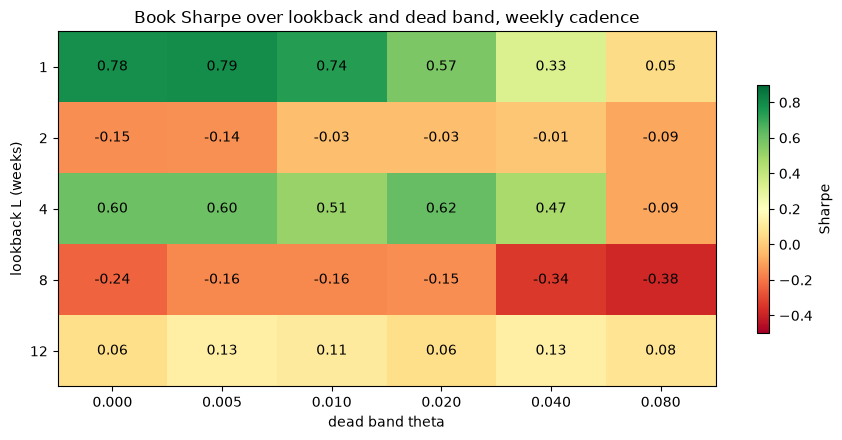

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(grid_sharpe.values, aspect='auto', cmap='RdYlGn', vmin=-0.5, vmax=0.9)
ax.set_xticks(np.arange(len(THETAS))); ax.set_xticklabels([f'{t:.3f}' for t in THETAS])
ax.set_yticks(np.arange(len(LOOKBACKS))); ax.set_yticklabels([str(L) for L in LOOKBACKS])
ax.set_xlabel('dead band theta')
ax.set_ylabel('lookback L (weeks)')
ax.set_title('Book Sharpe over lookback and dead band, weekly cadence')
for i in range(len(LOOKBACKS)):
    for j in range(len(THETAS)):
        v = grid_sharpe.values[i,j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', color='k', fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.7, label='Sharpe')
plt.tight_layout()
plt.show()


The green cells cluster on the L=1 and L=4 rows and are limited to small theta. The red rows on L=2 and L=8 stay red at every theta. No dead band turns a losing lookback into a winner, and no dead band lifts a winner beyond noise. The base finding that trend lives at L=1 and L=4 is stable to this axis.


## Turnover reduction

Sharpe is flat but flip rate is not. The dead band cuts turnover materially even where it does not help Sharpe. This matters for the cost model on the wider universe where per-symbol costs may be higher than the 10-perp median, and for live where impact scales with turnover.


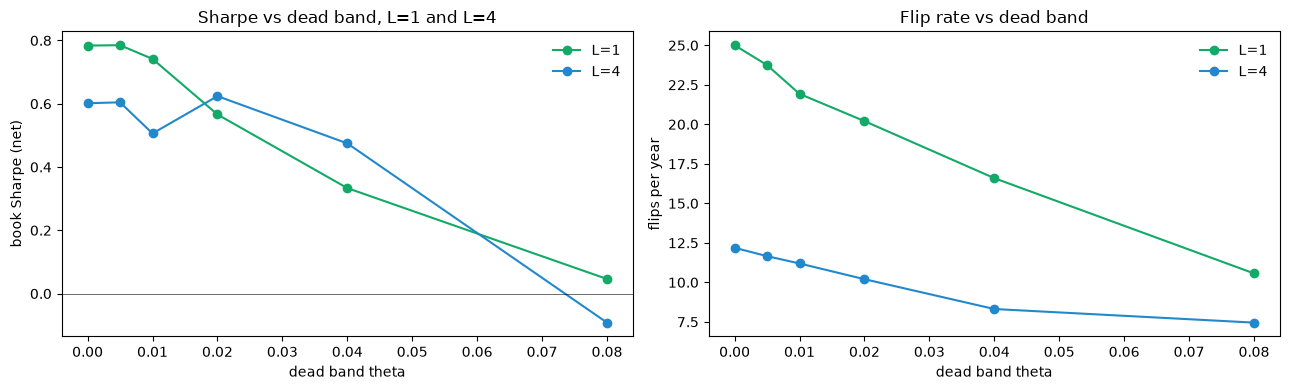

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for L, col in [(1, '#1a6'), (4, '#28c')]:
    ax1.plot(THETAS, sweep_w[sweep_w.L==L]['sharpe'].values, marker='o', color=col, label=f'L={L}')
ax1.axhline(0, color='k', lw=0.4)
ax1.set_xlabel('dead band theta')
ax1.set_ylabel('book Sharpe (net)')
ax1.set_title('Sharpe vs dead band, L=1 and L=4')
ax1.legend(frameon=False)

for L, col in [(1, '#1a6'), (4, '#28c')]:
    ax2.plot(THETAS, sweep_w[sweep_w.L==L]['flips_yr'].values, marker='o', color=col, label=f'L={L}')
ax2.set_xlabel('dead band theta')
ax2.set_ylabel('flips per year')
ax2.set_title('Flip rate vs dead band')
ax2.legend(frameon=False)
plt.tight_layout()
plt.show()


At L=1, theta=0.04 halves the flip rate from 25 to 17 per year at a cost of about 0.45 Sharpe. That trade is not worth it on this sample but the mechanism is intact, the dead band is genuinely filtering flips. At L=4 the flip rate is already low (12 per year at theta=0), so the band has less room to help on turnover.


## Daily cadence

Check the sign every day instead of every Sunday. A dead band is required or the flip rate explodes. If daily helps, it means the weekly grid was leaving information on the table by only sampling once a week. If daily hurts, it means the signal has no useful sub-weekly resolution and every extra check adds noise the band cannot filter.


book Sharpe (annualized daily) by L and theta, daily cadence
theta  0.000  0.005  0.010  0.020  0.040  0.080
L                                              
1       0.27   0.29   0.22   0.16   0.21   0.27
4       0.27   0.30   0.31   0.28   0.32   0.33


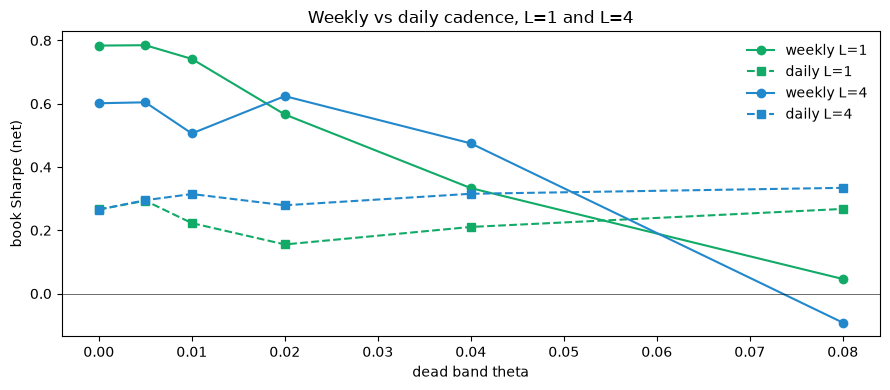

In [6]:
rows = []
for L in [1, 4]:
    for th in THETAS:
        pnl_df, flips_df = trend_pnl_daily(L, th)
        book = pnl_df.mean(axis=1)
        rows.append({
            'L': L, 'theta': th,
            'sharpe_daily': sharpe_d(book),
            'flips_yr': flips_df.mean().mean()*252,
        })
sweep_d = pd.DataFrame(rows)
grid_d = sweep_d.pivot(index='L', columns='theta', values='sharpe_daily').round(2)
print('book Sharpe (annualized daily) by L and theta, daily cadence')
print(grid_d)

fig, ax = plt.subplots(figsize=(9, 4))
for L, col in [(1, '#1a6'), (4, '#28c')]:
    ax.plot(THETAS, sweep_w[sweep_w.L==L]['sharpe'].values, marker='o', color=col, label=f'weekly L={L}')
    ax.plot(THETAS, sweep_d[sweep_d.L==L]['sharpe_daily'].values, marker='s', color=col, ls='--', label=f'daily L={L}')
ax.axhline(0, color='k', lw=0.4)
ax.set_xlabel('dead band theta')
ax.set_ylabel('book Sharpe (net)')
ax.set_title('Weekly vs daily cadence, L=1 and L=4')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Daily cadence sits at 0.2 to 0.3 Sharpe across every theta, well below the weekly line at 0.5 to 0.8. The gap is largest at small theta where daily is fighting the highest turnover. Even at theta=0.08 where daily flip rate falls to 13 per year (comparable to weekly), the daily book still runs at 0.27 Sharpe against weekly 0.05, because the daily signal is entering and exiting at daily granularity that does not line up with the weekly reversal windows the trailing return is measuring.

The signal is a weekly-scale phenomenon on this sample. Checking daily costs Sharpe.


## Cost sensitivity of the survivor

Weekly cadence and theta=0 was the winner in the sweep and is what the earlier notebooks already tested at 0x, 1x, 2x cost. Rerun that check on the small-theta neighbour (theta=0.005 at L=1) to confirm it survives cost.


cost_x             0.0   1.0   2.0
L_theta                           
L=1, theta=0.0    0.86  0.78  0.71
L=1, theta=0.005  0.86  0.79  0.71
L=4, theta=0.0    0.64  0.60  0.56
L=4, theta=0.02   0.66  0.62  0.59


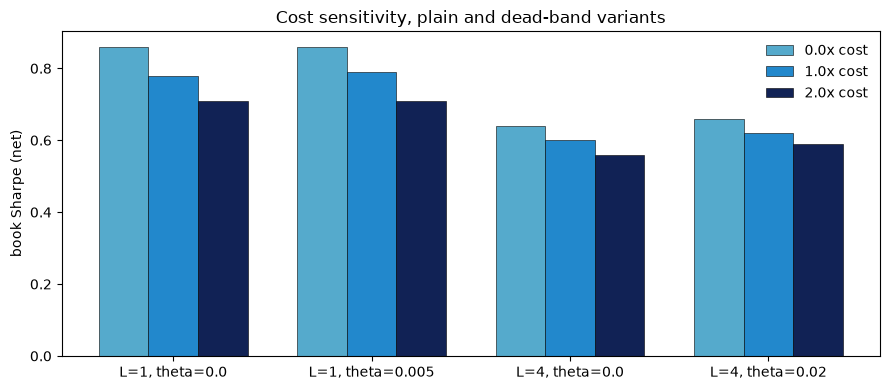

In [7]:
cost_mults = [0.0, 1.0, 2.0]
rows = []
for L, th in [(1, 0.0), (1, 0.005), (4, 0.0), (4, 0.02)]:
    for m in cost_mults:
        pnl_df, _ = trend_pnl_weekly(L, th, cost_mult=m)
        book = pnl_df.mean(axis=1)
        rows.append({'L_theta': f'L={L}, theta={th}', 'cost_x': m, 'sharpe': sharpe_w(book)})
cs = pd.DataFrame(rows).pivot(index='L_theta', columns='cost_x', values='sharpe').round(2)
print(cs)

fig, ax = plt.subplots(figsize=(9, 4))
w = 0.25
cells_x = list(cs.index)
x = np.arange(len(cells_x))
for i, m in enumerate(cost_mults):
    ax.bar(x + (i-1)*w, cs[m].values, width=w, label=f'{m}x cost',
           color=['#5ac','#28c','#125'][i], edgecolor='k', linewidth=0.4)
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(cells_x)
ax.set_ylabel('book Sharpe (net)')
ax.set_title('Cost sensitivity, plain and dead-band variants')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Every cell keeps its sign at 2x cost. The lift from the dead band is inside noise at every cost multiplier. The plain sign at theta=0 is not meaningfully better or worse than the small-theta neighbour under cost stress.


## Finding

The dead band does not lift the trend book on this sample. L=1 gains a hundredth of Sharpe at the smallest tested threshold and loses from there. L=4 has a non-monotone bump at theta=2% that is inside noise. L=2 and L=8 stay negative at every threshold, which means the sawtooth in the base grid is not a zero-crossing artifact, it is a feature of these lookback windows on this data.

Daily cadence loses across the whole grid, 0.2 to 0.3 Sharpe versus 0.5 to 0.8 at weekly. The trend signal has no useful sub-weekly information at these lookbacks. Weekly is not just the convenient choice, it is the right one on this sample.

The dead band does reduce turnover as intended, at L=1 the flip rate can be halved by theta=0.04 at a Sharpe cost of about 0.45. That trade is not worth it here but the mechanism is intact and may matter on the wider universe where per-symbol costs are higher and where impact scales with turnover.
